In [2]:
import numpy as np
import keras
from keras.applications.imagenet_utils import decode_predictions
import skimage.io 
import skimage.segmentation
import copy
import sklearn
import sklearn.metrics
from sklearn.linear_model import LinearRegression
import warnings

print('Notebook running: keras ', keras.__version__)
np.random.seed(42)

Notebook running: keras  2.12.0


In [3]:
inceptionV3_model = keras.applications.inception_v3.InceptionV3()

96112376/96112376 [==============================] - 56s 1us/step


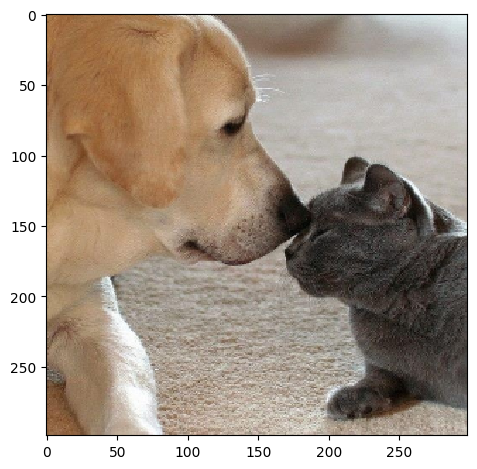

In [19]:
Xi = skimage.io.imread("https://arteagac.github.io/blog/lime_image/img/cat-and-dog.jpg")
Xi = skimage.transform.resize(Xi, (299,299)) 
Xi = (Xi - 0.5)*2 #Inception pre-processing
skimage.io.imshow(Xi/2+0.5) 

In [23]:
np.random.seed(42)
preds = inceptionV3_model.predict(Xi[np.newaxis,:,:,:])
decode_predictions(preds)[0]

1/1 [==============================] - 0s 91ms/step


[('n02099712', 'Labrador_retriever', 0.81829077),
 ('n02099601', 'golden_retriever', 0.015929896),
 ('n02093428', 'American_Staffordshire_terrier', 0.010066429),
 ('n02108422', 'bull_mastiff', 0.009287024),
 ('n02109047', 'Great_Dane', 0.008600942)]

In [6]:
top_pred_classes = preds[0].argsort()[-5:][::-1]
top_pred_classes  

array([208, 207, 180, 243, 246], dtype=int64)

In [7]:
superpixels = skimage.segmentation.quickshift(Xi, kernel_size=4,max_dist=200, ratio=0.2)
num_superpixels = np.unique(superpixels).shape[0]
num_superpixels

71

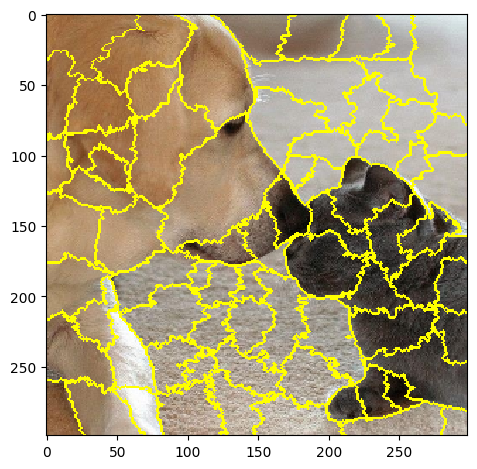

In [8]:
skimage.io.imshow(skimage.segmentation.mark_boundaries(Xi/2+0.5, superpixels))


In [9]:
num_perturb = 150
perturbations = np.random.binomial(1, 0.5, size=(num_perturb, num_superpixels))
perturbations[0]

array([0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1])

In [10]:
def perturb_image(img,perturbation,segments):
  active_pixels = np.where(perturbation == 1)[0]
  mask = np.zeros(segments.shape)
  for active in active_pixels:
      mask[segments == active] = 1 
  perturbed_image = copy.deepcopy(img)
  perturbed_image = perturbed_image*mask[:,:,np.newaxis]
  return perturbed_image

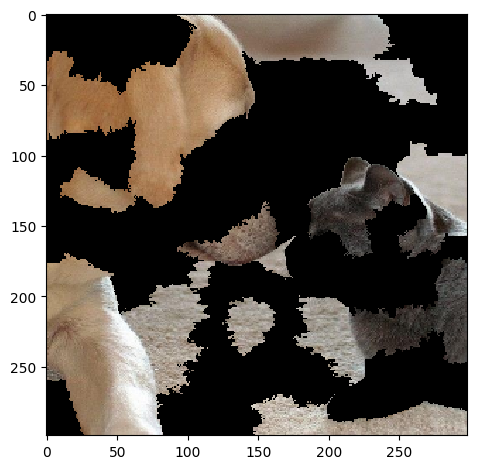

In [11]:
skimage.io.imshow(perturb_image(Xi/2+0.5,perturbations[0],superpixels))


In [12]:
predictions = []
for pert in perturbations:
  perturbed_img = perturb_image(Xi,pert,superpixels)
  pred = inceptionV3_model.predict(perturbed_img[np.newaxis,:,:,:])
  predictions.append(pred)

predictions = np.array(predictions)
predictions.shape

1/1 [==============================] - 0s 76ms/step


(150, 1, 1000)

In [13]:
original_image = np.ones(num_superpixels)[np.newaxis,:] #Perturbation with all superpixels enabled 
distances = sklearn.metrics.pairwise_distances(perturbations,original_image, metric='cosine').ravel()
distances.shape

(150,)

In [14]:
kernel_width = 0.25
weights = np.sqrt(np.exp(-(distances**2)/kernel_width**2)) #Kernel function
weights.shape

(150,)

In [15]:
class_to_explain = top_pred_classes[0]
simpler_model = LinearRegression()
simpler_model.fit(X=perturbations, y=predictions[:,:,class_to_explain], sample_weight=weights)
coeff = simpler_model.coef_[0]
coeff

array([-0.04296619,  0.02799017,  0.04571245, -0.05224008, -0.07217705,
        0.06416721, -0.04107938, -0.02964044,  0.21908682,  0.00919209,
        0.0640215 , -0.01974831,  0.03466753, -0.0091841 , -0.03375534,
        0.00317192,  0.04900161, -0.04561005,  0.04354822, -0.00409345,
        0.02386282,  0.01337584,  0.02604864,  0.01534014, -0.04270417,
       -0.01416829,  0.58651465, -0.03717823,  0.04399885,  0.0356312 ,
        0.0398755 ,  0.07288982,  0.10153657,  0.01986032,  0.01388947,
        0.06438237, -0.00204739,  0.03440243,  0.0109133 , -0.00317108,
       -0.03155908,  0.00931296, -0.05064653, -0.02518104, -0.02910484,
       -0.00390235,  0.08279687,  0.07153913,  0.01152604,  0.01835145,
       -0.07558479, -0.06266505, -0.05067241,  0.01195953, -0.00503731,
        0.0745106 ,  0.00246373,  0.00063429, -0.02255172, -0.01590917,
        0.03239259, -0.0388439 , -0.02666967, -0.04704959, -0.00461172,
        0.0354291 ,  0.08009371,  0.06429733, -0.06523961, -0.06

In [16]:
num_top_features = 4
top_features = np.argsort(coeff)[-num_top_features:] 
top_features

array([46, 32,  8, 26], dtype=int64)

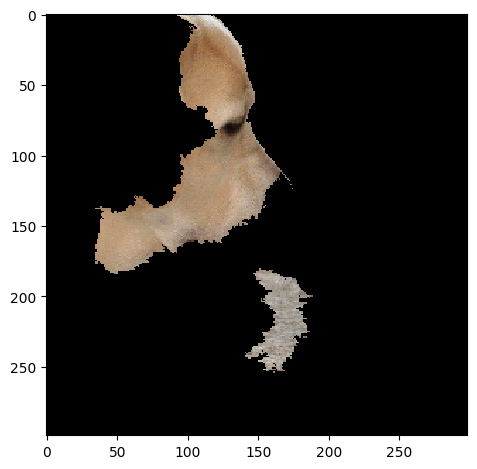

In [17]:
mask = np.zeros(num_superpixels) 
mask[top_features]= True #Activate top superpixels
skimage.io.imshow(perturb_image(Xi/2+0.5,mask,superpixels) )